In [6]:
# Setup: config + imports
import glob
import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

# Config
CROP_OUT_DIR = "../Data/AIRS-cropped"
VARNAME      = "co_mmr_midtrop"
MW_RATIO     = 28.01 / 44.01          # CO / CO2 molar-mass conversion
OUT_DIR      = "../Figures"
os.makedirs(OUT_DIR, exist_ok=True)

# Balanced window: 23 whole years
START_TS = pd.Timestamp("2003-01-01")
END_TS   = pd.Timestamp("2025-12-01")

## Interpolation to fill gaps in the data (2 months)

In [7]:
# Build gap-free monthly maps over the window, then the spatial-mean series.
crop_files = sorted(glob.glob(os.path.join(CROP_OUT_DIR, "*.nc")))
print(f"Found {len(crop_files)} cropped files")

# Load each month's (lat, lon) map: mean over orbit passes, ratio-corrected.
obs_maps = {}
lons = lats = None
for f in crop_files:
    stem = os.path.splitext(os.path.basename(f))[0]
    date = pd.Timestamp(f"{stem[:4]}-{stem[4:]}-01")
    if not (START_TS <= date <= END_TS):
        continue
    ds_g = xr.open_dataset(f, decode_timedelta=False)
    if lons is None:
        lons = ds_g["lon"].values
        lats = ds_g["lat"].values
    obs_maps[date] = ds_g[VARNAME].mean(dim="orbit_pass", skipna=True).values * MW_RATIO
    ds_g.close()

n_lat, n_lon = len(lats), len(lons)

# Full monthly calendar over the window.
months = pd.date_range(START_TS, END_TS, freq="MS")

# Stack into a (time, lat, lon) cube; missing months stay all-NaN.
raw_maps = np.full((len(months), n_lat, n_lon), np.nan)
has_obs = np.zeros(len(months), dtype=bool)
for i, d in enumerate(months):
    if d in obs_maps:
        raw_maps[i] = obs_maps[d]
        has_obs[i] = True
is_interp = ~has_obs

# Interpolate maps in time, per pixel, to fill missing months.
final_maps = xr.DataArray(
    raw_maps, dims=("time", "lat", "lon"),
    coords={"time": months, "lat": lats, "lon": lons},
)
final_maps = (final_maps.interpolate_na(dim="time", method="linear")
                        .bfill("time").ffill("time"))

# Time series = spatial mean of each map.
ts_dates = months
ts_co    = final_maps.mean(dim=("lat", "lon"), skipna=True).values

# Diagnostics.
n_pix = n_lat * n_lon
filled_dates = [d.strftime('%Y-%m') for d in months[is_interp]]
print(f"Calendar months   : {len(months)}   ({START_TS:%b %Y} - {END_TS:%b %Y})")
print(f"Observed maps      : {has_obs.sum()}")
print(f"Reconstructed maps : {is_interp.sum()}  -> {filled_dates}")
print(f"Grid per map       : {n_lat} lat x {n_lon} lon = {n_pix} pixels")
for i in np.where(is_interp)[0]:
    n_valid_orig = int(np.isfinite(raw_maps[i]).sum())
    n_valid_new  = int(np.isfinite(final_maps.values[i]).sum())
    print(f"   {months[i].strftime('%Y-%m')}: filled {n_valid_new - n_valid_orig} "
          f"pixels  ->  map mean = {ts_co[i]:.4e} kg/kg")

n_dead = int(np.isnan(final_maps.values).all(axis=0).sum())
print(f"Pixels never observed (left NaN): {n_dead}")
print(f"Date range : {ts_dates[0].date()}  ->  {ts_dates[-1].date()}")
print(f"CO range   : {np.nanmin(ts_co):.4e} - {np.nanmax(ts_co):.4e}  kg/kg")

Found 279 cropped files
Calendar months   : 276   (Jan 2003 - Dec 2025)
Observed maps      : 274
Reconstructed maps : 2  -> ['2023-09', '2025-12']
Grid per map       : 36 lat x 61 lon = 2196 pixels
   2023-09: filled 2196 pixels  ->  map mean = 8.5295e-08 kg/kg
   2025-12: filled 2196 pixels  ->  map mean = 7.6991e-08 kg/kg
Pixels never observed (left NaN): 0
Date range : 2003-01-01  ->  2025-12-01
CO range   : 7.6991e-08 - 1.1788e-07  kg/kg


## Mean and SD maps

Stack shape : (276, 36, 61)   (2003-01 - 2025-12)
Mean range  : 8.1518e-08 - 9.8430e-08  kg/kg
Std  range  : 4.7108e-09 - 1.5814e-08  kg/kg


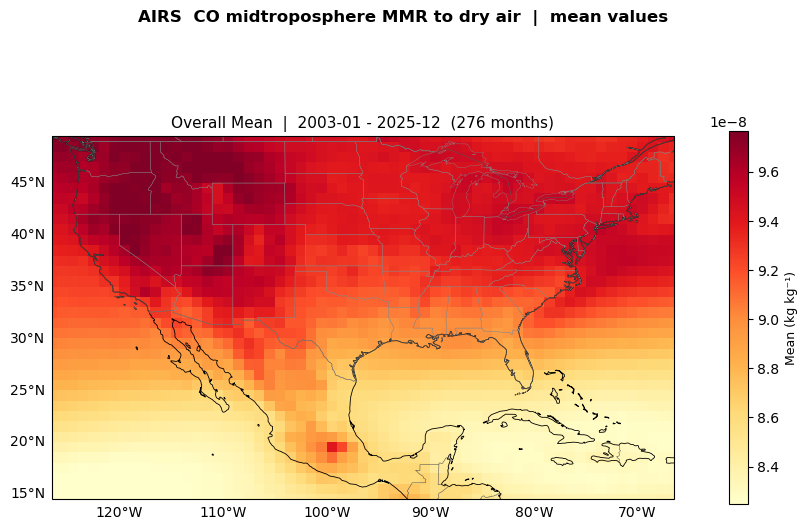

Saved -> ../Figures\co_mmr_midtrop_mean_2003_2025.png


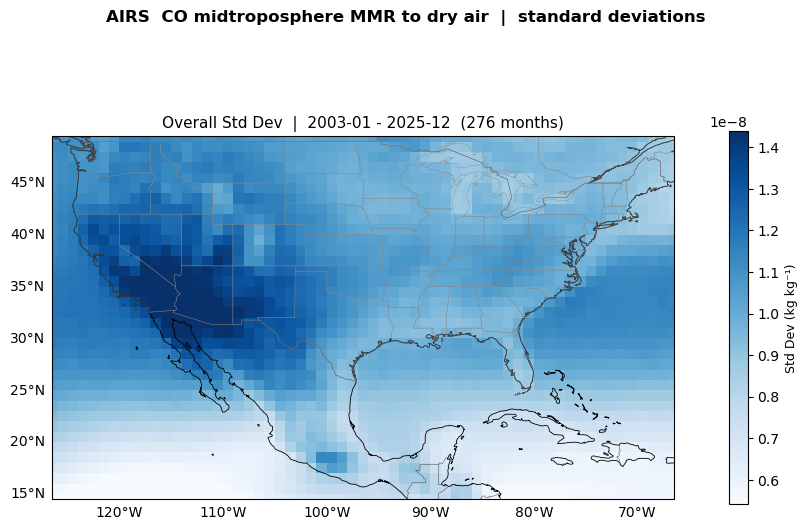

Saved -> ../Figures\co_mmr_midtrop_std_2003_2025.png


In [8]:
# Pixel-wise mean & std across all months of the gap-free cube.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

FIG_DIR = r"../Figures"
os.makedirs(FIG_DIR, exist_ok=True)

stack   = final_maps.values
co_mean = np.nanmean(stack, axis=0)
co_std  = np.nanstd (stack, axis=0)

n_months    = stack.shape[0]
label_first = months[0].strftime("%Y-%m")
label_last  = months[-1].strftime("%Y-%m")

print(f"Stack shape : {stack.shape}   ({label_first} - {label_last})")
print(f"Mean range  : {np.nanmin(co_mean):.4e} - {np.nanmax(co_mean):.4e}  kg/kg")
print(f"Std  range  : {np.nanmin(co_std ):.4e} - {np.nanmax(co_std ):.4e}  kg/kg")

# Map extent from data coords.
lon_min, lon_max = float(lons.min()), float(lons.max())
lat_min, lat_max = float(lats.min()), float(lats.max())


def draw_map(fig, ax, data, cmap, label, title):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

    pcm = ax.pcolormesh(
        lons, lats, data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=np.nanpercentile(data, 2), vmax=np.nanpercentile(data, 98),
        shading="nearest",
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False

    cb = fig.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)


# Mean map.
fig_mean, ax_mean = plt.subplots(
    figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
draw_map(fig_mean, ax_mean, co_mean, plt.cm.YlOrRd,
         "Mean (kg kg⁻¹)",
         f"Overall Mean  |  {label_first} - {label_last}  ({n_months} months)")
fig_mean.suptitle(
    "AIRS  CO midtroposphere MMR to dry air  |  mean values ",
    fontsize=12, fontweight="bold",
)
out_mean = os.path.join(FIG_DIR, "co_mmr_midtrop_mean_2003_2025.png")
fig_mean.savefig(out_mean, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_mean)

# Std-dev map.
fig_std, ax_std = plt.subplots(
    figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
draw_map(fig_std, ax_std, co_std, plt.cm.Blues,
         "Std Dev (kg kg⁻¹)",
         f"Overall Std Dev  |  {label_first} - {label_last}  ({n_months} months)")
fig_std.suptitle(
    "AIRS  CO midtroposphere MMR to dry air  |  standard deviations",
    fontsize=12, fontweight="bold",
)
out_std = os.path.join(FIG_DIR, "co_mmr_midtrop_std_2003_2025.png")
fig_std.savefig(out_std, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_std)

## Per-pixel linear fit using ordinary least squares 

In [9]:
# per-pixel linear fit in time
yr = (months - months[0]).days.values / 365.25            # decimal years

Y    = final_maps.values
yr_c = yr - yr.mean()
pixel_slope     = np.tensordot(yr_c, Y - Y.mean(axis=0, keepdims=True),
                               axes=(0, 0)) / np.sum(yr_c**2)   # (lat, lon) kg/kg/yr
pixel_intercept = Y.mean(axis=0) - pixel_slope * yr.mean()      # (lat, lon)

dead = np.all(np.isnan(Y), axis=0)
pixel_slope[dead]     = np.nan
pixel_intercept[dead] = np.nan

# Fitted trend line and residual (detrended) fields.
trend_field = xr.DataArray(
    pixel_intercept[None] + pixel_slope[None] * yr[:, None, None],
    dims=("time", "lat", "lon"), coords=final_maps.coords,
)
detr_field = (final_maps - trend_field).transpose("time", "lat", "lon")

print(f"Per-pixel fit : slope {np.nanmin(pixel_slope):.3e} - {np.nanmax(pixel_slope):.3e} kg/kg/yr")

Per-pixel fit : slope -8.607e-10 - -1.189e-10 kg/kg/yr


## Plot of slopes at each grid point

Per-pixel slope grid : (36, 61)  (lat x lon)
Slope range          : -8.607e-10 - -1.189e-10  kg/kg/yr
Domain-mean slope    : -4.735e-10  kg/kg/yr


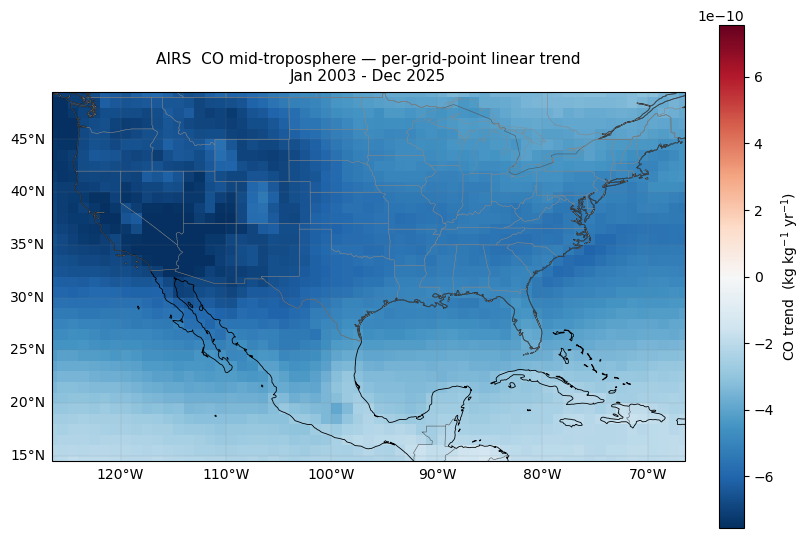

Saved -> ../Figures\spatial_co_trend_slope_2003_2025.png


In [10]:
# Per-pixel slope map from the single fit.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

slope = pixel_slope

print(f"Per-pixel slope grid : {slope.shape}  (lat x lon)")
print(f"Slope range          : {np.nanmin(slope):.3e} - {np.nanmax(slope):.3e}  kg/kg/yr")
print(f"Domain-mean slope    : {np.nanmean(slope):.3e}  kg/kg/yr")

# Plot.
ext = [float(lons.min()), float(lons.max()),
       float(lats.min()), float(lats.max())]

vmax_s = np.nanpercentile(np.abs(slope), 98)

fig_s, ax_s = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
ax_s.set_extent(ext, crs=ccrs.PlateCarree())
ax_s.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
ax_s.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
ax_s.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

pcm = ax_s.pcolormesh(
    lons, lats, slope,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-vmax_s, vmax=vmax_s, shading="auto",
)
cb = fig_s.colorbar(pcm, ax=ax_s, orientation="vertical", shrink=0.85, pad=0.02)
cb.set_label("CO trend  (kg kg$^{-1}$ yr$^{-1}$)", fontsize=10)

gl = ax_s.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax_s.set_title(
    "AIRS  CO mid-troposphere — per-grid-point linear trend\n"
    f"{months[0].strftime('%b %Y')} - {months[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)

out_s = os.path.join(OUT_DIR, "spatial_co_trend_slope_2003_2025.png")
fig_s.savefig(out_s, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_s)

## Mean slope and intercept 

In [11]:
# Mean-series trend from the per-pixel fit: a, b are the spatial mean of the
# pixel coefficients; uncertainties / R2 / RMSE from the mean-series residual.
a = np.nanmean(pixel_slope)
b = np.nanmean(pixel_intercept)

fit_line = b + a * yr                 # straight line 
resid    = ts_co - fit_line
n        = len(yr)

ss_res = np.sum(resid**2)
ss_tot = np.sum((ts_co - ts_co.mean())**2)
r2     = 1 - ss_res / ss_tot
rmse   = np.sqrt(ss_res / n)

# OLS parameter errors from the residual (unbiased, n-2).
Sxx   = np.sum((yr - yr.mean())**2)
s2    = ss_res / (n - 2)
a_err = np.sqrt(s2 / Sxx)
b_err = np.sqrt(s2 * (1 / n + yr.mean()**2 / Sxx))

print(f"Linear regression  y = a*x + b   (x in years since {ts_dates[0].date()})")
print(f"  slope a     = {a:.6e}  +/- {a_err:.2e}  kg/kg per year")
print(f"  intercept b = {b:.6e}  +/- {b_err:.2e}  kg/kg")
print(f"  R^2         = {r2:.4f}")
print(f"  RMSE        = {rmse:.4e}  kg/kg")
print(f"  N points    = {n}")

Linear regression  y = a*x + b   (x in years since 2003-01-01)
  slope a     = -4.735434e-10  +/- 7.57e-11  kg/kg per year
  intercept b = 9.575737e-08  +/- 1.00e-09  kg/kg
  R^2         = 0.1249
  RMSE        = 8.3210e-09  kg/kg
  N points    = 276


## Timeseries of the mean values with linear fit

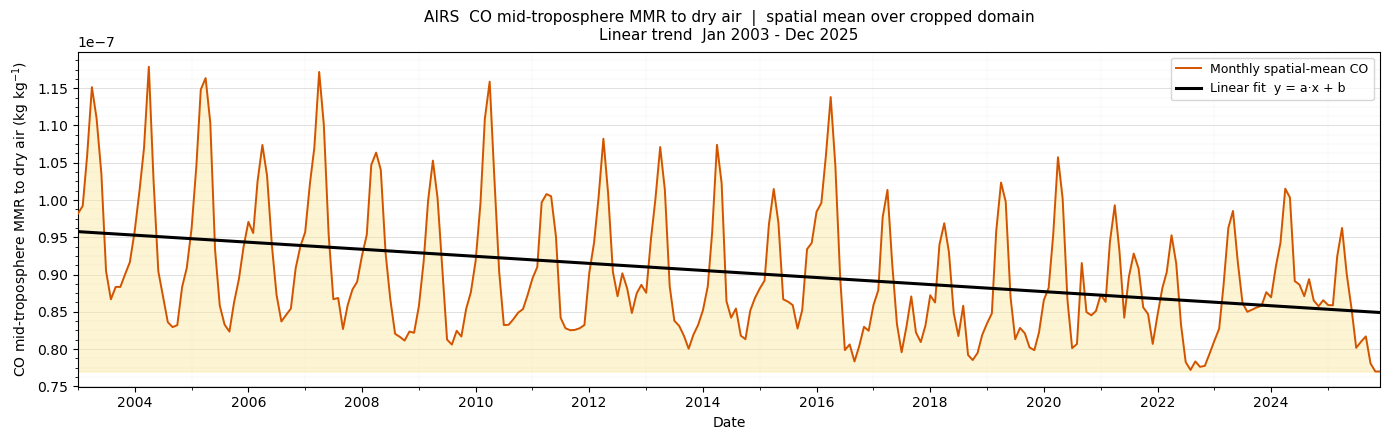

Saved -> ../Figures\timeseries_co_linear_trend_2003_2025.png


In [12]:
# Plot: monthly series + fitted regression line.
fig_ts, ax_ts = plt.subplots(figsize=(14, 4.5))

ax_ts.plot(ts_dates, ts_co, lw=1.4, color="#d35400", zorder=3,
           label="Monthly spatial-mean CO")
ax_ts.fill_between(ts_dates, ts_co, ts_co.min(),
                   alpha=0.45, color="#f9e79f", zorder=2)

ax_ts.plot(ts_dates, fit_line, lw=2.2, color="k", zorder=4,
           label="Linear fit  y = a·x + b")

ax_ts.legend(fontsize=9, loc="upper right")

ax_ts.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  spatial mean over cropped domain\n"
    f"Linear trend  {ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_ts.set_ylabel("CO mid-troposphere MMR to dry air (kg kg$^{-1}$)", fontsize=10)
ax_ts.set_xlabel("Date", fontsize=10)

ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.xaxis.set_minor_locator(mdates.YearLocator())
ax_ts.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_ts.grid(axis="y", which="major", lw=0.5, alpha=0.55)
ax_ts.grid(axis="y", which="minor", lw=0.2, alpha=0.3)
ax_ts.grid(axis="x", which="minor", lw=0.2, alpha=0.25)
ax_ts.set_xlim(ts_dates[0], ts_dates[-1])

fig_ts.tight_layout()

out_ts = os.path.join(OUT_DIR, "timeseries_co_linear_trend_2003_2025.png")
fig_ts.savefig(out_ts, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_ts)

## Subtracting the linear fit from data

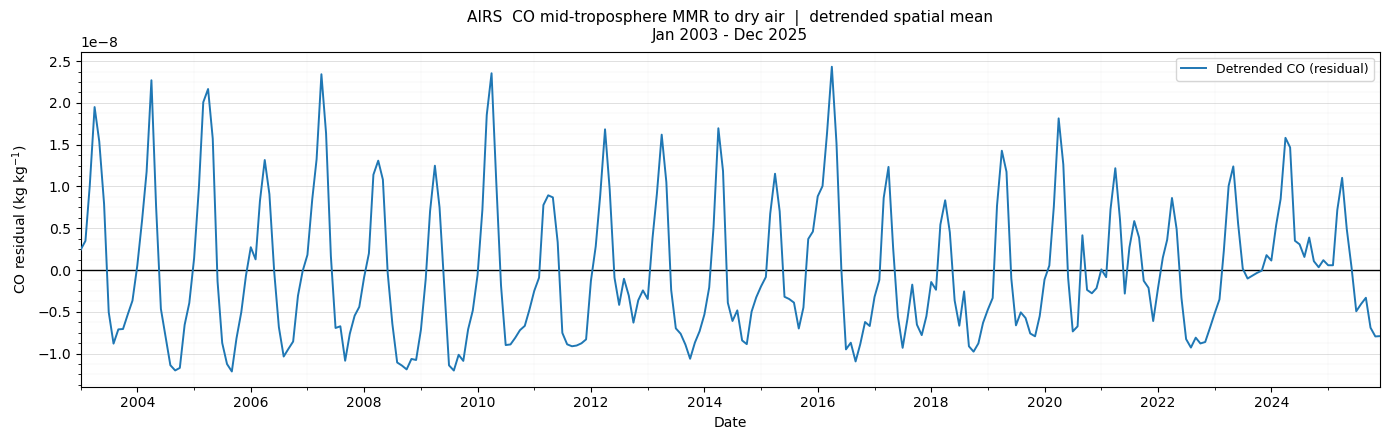

Saved -> ../Figures\timeseries_co_detrended_2003_2025.png


In [13]:
# Detrended series = spatial mean of the per-pixel detrended field.
detrended = detr_field.mean(("lat", "lon")).values

fig_dt, ax_dt = plt.subplots(figsize=(14, 4.5))
ax_dt.axhline(0, color="k", lw=1, zorder=2)
ax_dt.plot(ts_dates, detrended, lw=1.4, color="#1f77b4", zorder=3,
           label="Detrended CO (residual)")

ax_dt.legend(fontsize=9, loc="upper right")
ax_dt.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  detrended spatial mean\n"
    f"{ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_dt.set_ylabel("CO residual (kg kg$^{-1}$)", fontsize=10)
ax_dt.set_xlabel("Date", fontsize=10)

ax_dt.xaxis.set_major_locator(mdates.YearLocator(2))
ax_dt.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_dt.xaxis.set_minor_locator(mdates.YearLocator())
ax_dt.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_dt.grid(axis="y", which="major", lw=0.5, alpha=0.55)
ax_dt.grid(axis="y", which="minor", lw=0.2, alpha=0.3)
ax_dt.grid(axis="x", which="minor", lw=0.2, alpha=0.25)
ax_dt.set_xlim(ts_dates[0], ts_dates[-1])

fig_dt.tight_layout()
out_dt = os.path.join(OUT_DIR, "timeseries_co_detrended_2003_2025.png")
fig_dt.savefig(out_dt, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_dt)

## Exploratory EOF analysis

Mode 1: 82.3% of variance
Mode 2: 7.1% of variance
Mode 3: 3.7% of variance
Mode 4: 1.2% of variance
Mode 5: 0.9% of variance
Mode 6: 0.6% of variance
Mode 7: 0.5% of variance
Mode 8: 0.4% of variance
Mode 9: 0.3% of variance
Mode 10: 0.3% of variance


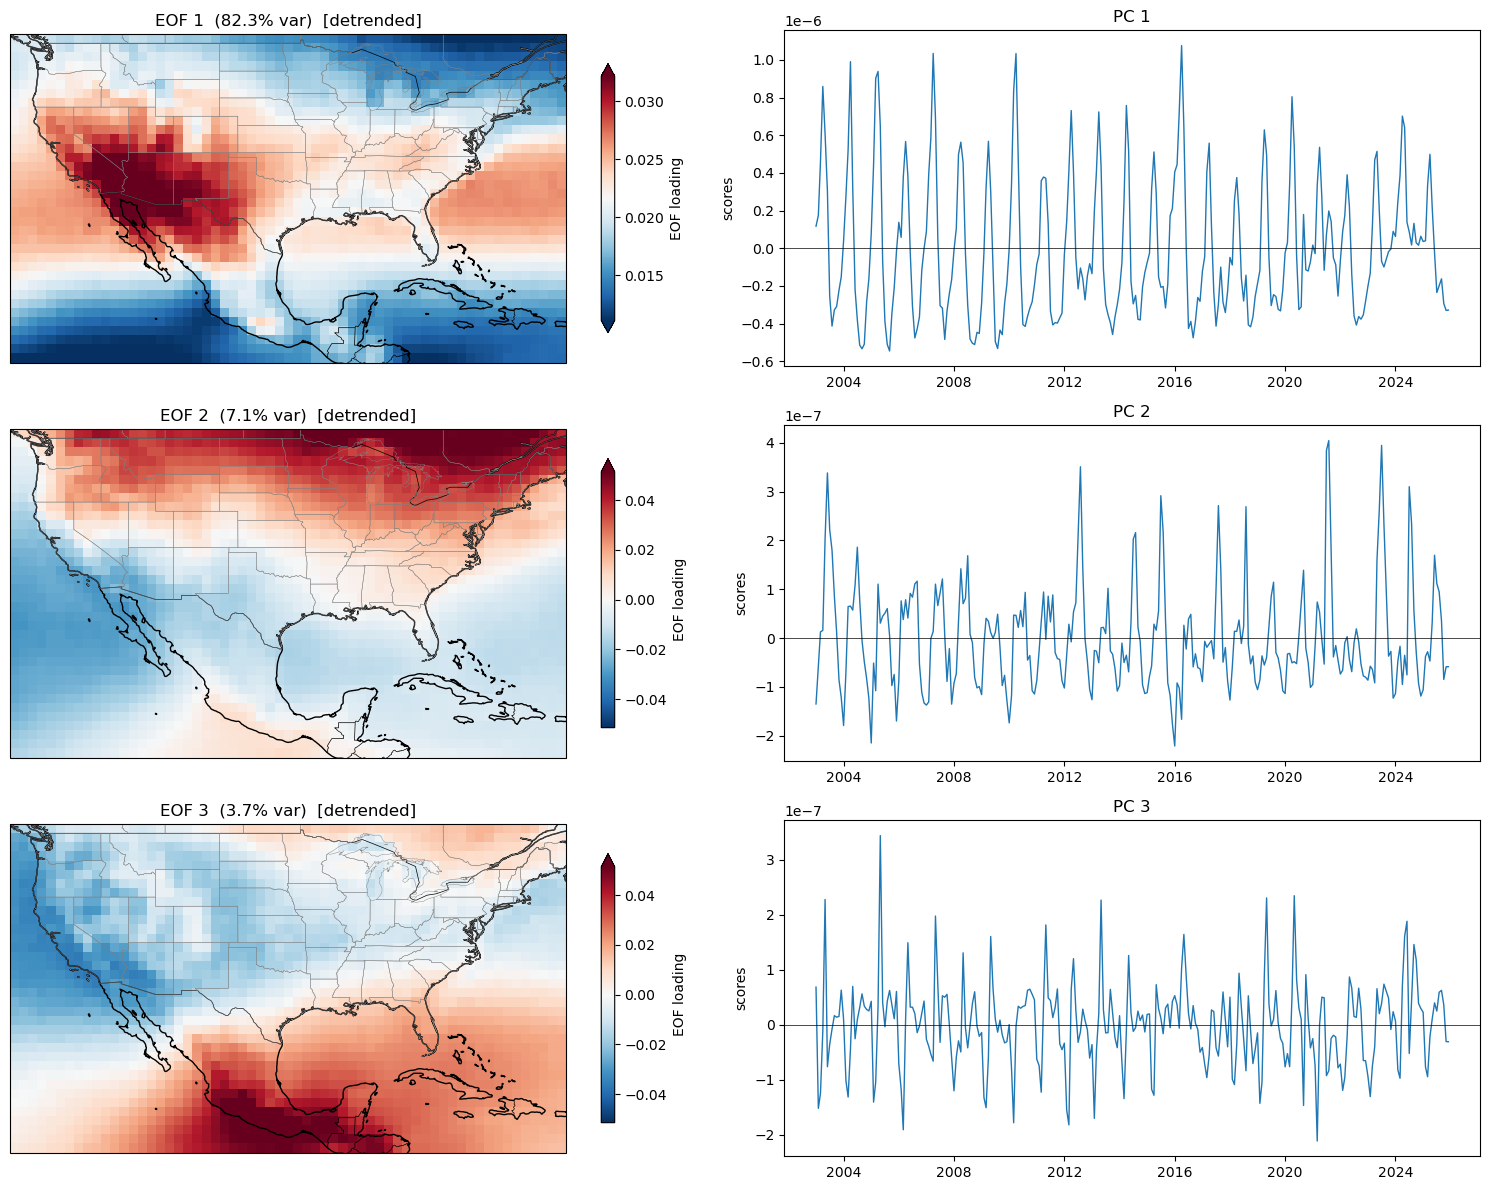

Saved -> ../Figures\eof_detrended_2003_2025.png


In [14]:
# EOF on the per-pixel detrended field (no climatology removed).
from xeofs.single import EOF

model = EOF(n_modes=10, use_coslat=True)
model.fit(detr_field, dim="time")
eofs   = model.components()                       # (mode, lat, lon)
pcs    = model.scores()                           # (mode, time)
expvar = model.explained_variance_ratio().values * 100
for i, v in enumerate(expvar, start=1):
    print(f"Mode {i}: {v:.1f}% of variance")

# Plot first 3 modes: spatial pattern + PC.
n_show = 3
fig_eof = plt.figure(figsize=(15, 4 * n_show))
for i in range(n_show):
    ax_map = fig_eof.add_subplot(n_show, 2, 2*i + 1, projection=ccrs.PlateCarree())
    eofs.sel(mode=i+1).plot(
        ax=ax_map, transform=ccrs.PlateCarree(), cmap="RdBu_r", robust=True,
        cbar_kwargs={"label": "EOF loading", "shrink": 0.8},
    )
    ax_map.coastlines()
    ax_map.add_feature(cfeature.BORDERS, lw=0.5)
    ax_map.add_feature(cfeature.STATES, lw=0.3, edgecolor="gray")
    ax_map.set_title(f"EOF {i+1}  ({expvar[i]:.1f}% var)  [detrended]")

    ax_pc = fig_eof.add_subplot(n_show, 2, 2*i + 2)
    pcs.sel(mode=i+1).plot(ax=ax_pc, lw=1)
    ax_pc.axhline(0, color="k", lw=0.5)
    ax_pc.set_title(f"PC {i+1}")
    ax_pc.set_xlabel("")

plt.tight_layout()
out_eof = os.path.join(OUT_DIR, "eof_detrended_2003_2025.png")
fig_eof.savefig(out_eof, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_eof)

## Harmonic analysis : 12 months, 6 months and 4 months harmonics

At every spatial grid point, the time series of the data is mathematically modeled as a superposition of fundamental cyclical waves—specifically, annual, semi-annual, and terannual cycles. Each cycle is initially constructed from a pair of sine and cosine functions, $a\cos(\omega t) + b\sin(\omega t)$. A least-squares regression is applied at each individual grid point to calculate the specific coefficients ($a$ and $b$) that best fit the model to the observed data. Once these coefficients are determined, the components are arranged into a standard sine convention, $A\sin(\omega t + \phi)$, to extract intuitive physical wave properties. The amplitude ($A$), representing the maximum strength of the cycle, is derived using the Pythagorean theorem $\sqrt{a^2 + b^2}$, and the phase ($\phi$), representing the timing of the cycle's peak, is found via the inverse tangent $\arctan(a/b)$. Finally, to allow for direct temporal comparison across different wave frequencies, the resulting phase angles are proportionally scaled to a unified 12-month calendar, ensuring that a given angular shift universally corresponds to the exact same physical time step across all cycles.

12-month: amp 3.52e-09 - 1.78e-08 kg/kg
 6-month: amp 1.06e-09 - 7.56e-09 kg/kg
 4-month: amp 9.36e-10 - 5.53e-09 kg/kg


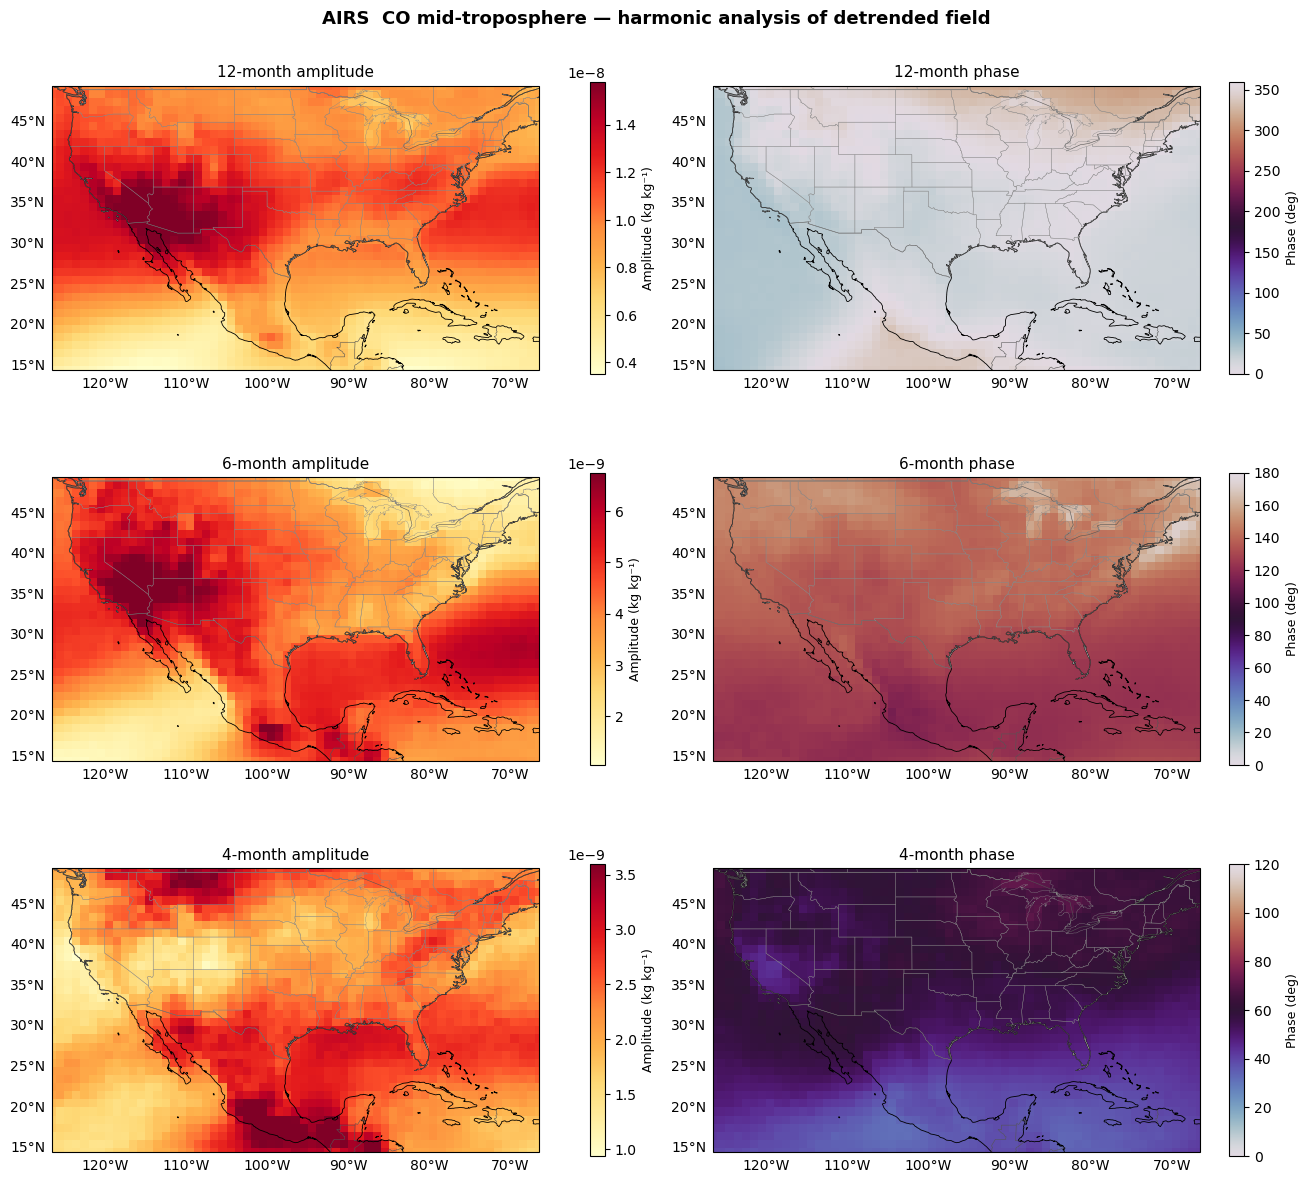

Saved -> ../Figures\harmonics_amp_phase_2003_2025.png


In [15]:
# Harmonic analysis of the detrended field: 12-, 6-, 4-month harmonics.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

periods = [12, 6, 4]                                   # months
t = np.arange(len(months))                            # month index

# Design matrix: a cos/sin pair per harmonic.
cols = []
for P in periods:
    w = 2 * np.pi / P
    cols += [np.cos(w * t), np.sin(w * t)]
M = np.column_stack(cols)                             # (time, 2*K)

# Least-squares fit at every pixel at once.
Yd = detr_field.values.reshape(len(months), -1)       # (time, pixels)
coef, *_ = np.linalg.lstsq(M, Yd, rcond=None)         # (2*K, pixels)

# Sine convention y = A*sin(wt + phase): a = A*sin(ph), b = A*cos(ph).
# Phase as angle of the annual cycle (deg): full 360 over 12 months, so the
# k-th harmonic spans only 360*P/12 deg (360, 180, 120 for 12-, 6-, 4-month).
amp, pha, pha_max = {}, {}, {}
for k, P in enumerate(periods):
    a_k = coef[2*k].reshape(n_lat, n_lon)
    b_k = coef[2*k + 1].reshape(n_lat, n_lon)
    amp[P] = np.hypot(a_k, b_k)                        # kg/kg
    pha[P] = (np.rad2deg(np.arctan2(a_k, b_k)) % 360) * (P / 12)   # deg, [0, 30*P)
    pha_max[P] = 360 * P / 12
    print(f"{P:2d}-month: amp {np.nanmin(amp[P]):.2e} - {np.nanmax(amp[P]):.2e} kg/kg")

# Plot amplitude and phase maps for each harmonic.
ext = [float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())]

fig_h, axes_h = plt.subplots(
    len(periods), 2, figsize=(13, 4 * len(periods)),
    subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True,
)


def harm_map(ax, data, cmap, label, title, vmin=None, vmax=None):
    ax.set_extent(ext, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")
    pcm = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(),
                        cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False
    cb = fig_h.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)


for r, P in enumerate(periods):
    harm_map(axes_h[r, 0], amp[P], "YlOrRd", "Amplitude (kg kg⁻¹)",
             f"{P}-month amplitude", vmax=np.nanpercentile(amp[P], 98))
    harm_map(axes_h[r, 1], pha[P], "twilight", "Phase (deg)",
             f"{P}-month phase", vmin=0, vmax=pha_max[P])

fig_h.suptitle("AIRS  CO mid-troposphere — harmonic analysis of detrended field",
               fontsize=13, fontweight="bold")
out_h = os.path.join(OUT_DIR, "harmonics_amp_phase_2003_2025.png")
fig_h.savefig(out_h, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_h)

In [16]:
# Variance of the detrended data captured by each harmonic.
# Harmonics are orthogonal over the 23-yr record, so var = amp^2/2 and they add.
var_data = np.nansum(detr_field.var("time").values)        # domain-total variance

print("Variance explained (domain total):")
cum = 0.0
for P in periods:
    frac = 100 * np.nansum(amp[P]**2 / 2) / var_data
    cum += frac
    print(f"  {P:2d}-month: {frac:5.1f}%")
print(f"  total (12+6+4): {cum:5.1f}%")
print(f"  residual      : {100 - cum:5.1f}%")

Variance explained (domain total):
  12-month:  57.5%
   6-month:  10.6%
   4-month:   3.1%
  total (12+6+4):  71.3%
  residual      :  28.7%


## Sanity check - data reconstruction from the output of harmonic analysis

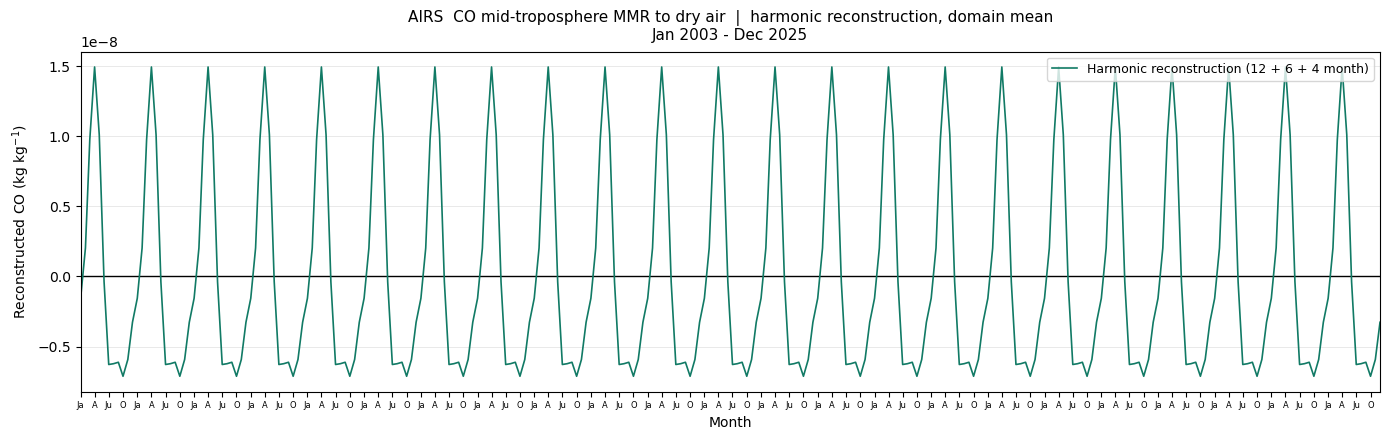

Saved -> ../Figures\timeseries_co_reconstructed_2003_2025.png


In [17]:
# Reconstruct the seasonal field from the harmonic fit, plot its domain mean.
from matplotlib.ticker import FuncFormatter

reconstructed = xr.DataArray(
    (M @ coef).reshape(len(months), n_lat, n_lon),
    dims=("time", "lat", "lon"), coords=detr_field.coords,
)
recon_ts = reconstructed.mean(("lat", "lon")).values

fig_r, ax_r = plt.subplots(figsize=(14, 4.5))
ax_r.axhline(0, color="k", lw=1, zorder=2)
ax_r.plot(ts_dates, recon_ts, lw=1.2, color="#117a65",
          label="Harmonic reconstruction (12 + 6 + 4 month)")
ax_r.legend(fontsize=9, loc="upper right")

ax_r.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  harmonic reconstruction, domain mean\n"
    f"{ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_r.set_ylabel("Reconstructed CO (kg kg$^{-1}$)", fontsize=10)
ax_r.set_xlabel("Month", fontsize=10)

# Ticks at Jan/Apr/Jul/Oct, labelled by letter.
letters = {1: "Ja", 4: "A", 7: "Ju", 10: "O"}
ax_r.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax_r.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: letters.get(mdates.num2date(x).month, "")))
ax_r.tick_params(axis="x", labelsize=6)
ax_r.grid(axis="y", lw=0.4, alpha=0.5)
ax_r.set_xlim(ts_dates[0], ts_dates[-1])

fig_r.tight_layout()
out_r = os.path.join(OUT_DIR, "timeseries_co_reconstructed_2003_2025.png")
fig_r.savefig(out_r, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_r)

In [18]:
# Month of max / min of the reconstructed seasonal cycle (domain mean).
recon_by_month = pd.Series(recon_ts, index=months).groupby(months.month).mean()
mx, mn = recon_by_month.idxmax(), recon_by_month.idxmin()
mname = lambda m: pd.Timestamp(2000, m, 1).strftime("%B")

print(f"Max: {mname(mx)}  ({recon_by_month[mx]:.4e} kg/kg)")
print(f"Min: {mname(mn)}  ({recon_by_month[mn]:.4e} kg/kg)")
print(f"Peak-to-peak: {recon_by_month[mx] - recon_by_month[mn]:.4e} kg/kg")

Max: April  (1.4942e-08 kg/kg)
Min: October  (-7.1146e-09 kg/kg)
Peak-to-peak: 2.2057e-08 kg/kg
